# Exploratory Data Analysis — Post-Earnings Announcement Drift (PEAD) Project

**Post-Earnings Announcement Drift: Multimodal ML Framework for S&P 500 Stocks**

This notebook consolidates the project's exploratory data analysis into a single, comprehensive
reference covering every data source used in modeling:

1. Data sources & table construction
2. Feature engineering reference
3. Descriptive statistics
4. Missing value analysis
5. Outlier detection
6. Correlation & relationship analysis
7. Class distribution analysis
8. Target variable definition
9. PEAD signal analysis (the core hypothesis this project tests)
10. Feature importance (mutual information)
11. Transcript & management commentary analysis
12. News sentiment analysis
13. Analyst coverage signal
14. Dimensionality reduction (PCA)
15. Summary of findings & preprocessing plan

In [65]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import os
import re
from bisect import bisect_left

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [66]:
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_rows(15)

# Presentation palette (used consistently across all figures)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['font.size'] = 10
NAVY, GOLD, RED, GREEN, MUTED = "#1E3A6E", "#D9A441", "#B23A2E", "#2E7D32", "#6E6E6E"

---
## 1. Data Sources & Table Construction

The final modeling table is assembled by joining five staged feature tables on `(symbol, earnings_date)`:

| Source | File | Content |
|---|---|---|
| Technical | `tech_modeling_table.parquet` | Price/volume/momentum/volatility indicators, pivoted t-10..t+10 around each earnings date; also carries the regression/classification targets |
| Fundamentals | `fundamentalIndicators/modeling_fundamentals.parquet` | EPS surprise, revenue/margin growth, leverage, profitability (QoQ) |
| Transcript sentiment | `finbert_tx_agg_weighted.parquet` | FinBERT positive/negative probability aggregated over each earnings call, plus GICS sector |
| News sentiment | `nz_sentiment.parquet` | AlphaVantage news sentiment, pre- and post-earnings windows |

Each row represents one earnings event (one symbol, one quarter).

In [69]:
df_tech = pl.read_parquet("../data/model_staging/tech_modeling_table.parquet")

df_fund = pl.read_parquet("../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet")
df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "reportedEPS", "estimatedEPS", "surprise", "surprisePercentage",
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin", "gross_margin_qoq",
    "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin", "fcf_margin_qoq",
    "roe", "roe_qoq",
]).with_columns(
    pl.col("surprisePercentage").cast(pl.Float64, strict=False)
)

df_finbert_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert_raw.select([
    "symbol", pl.col("reportedDate").alias("earnings_date"), "pos_prob", "neg_prob",
])

df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    "symbol", pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre", "relevance_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post", "relevance_score_post",
])

# sector one-hot (from FinBERT table, avoids a second read)
df_sector = df_finbert_raw.select(["symbol", "sector"]).unique()
df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
sectors = sorted(df_sector["sector"].unique().to_list())
df_sector_oh = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
])

# join everything
df_model = df_tech.join(df_fund, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_nz, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_sector.select(["symbol", "sector"]), on="symbol", how="left")
df_model = df_model.join(df_sector_oh.drop("sector"), on="symbol", how="left")

# derived labels used throughout this notebook
df_model = df_model.with_columns([
    (pl.col("surprisePercentage") > 0).cast(pl.Int8).alias("beat"),
    (pl.col("target_return") > 0).cast(pl.Int8).alias("target_direction"),
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.month().alias("month"),
])

# A handful of ratio features produce NaN floats rather than nulls. Polars' null_count()
# does not see these, and NaN silently poisons mean()/std() downstream, so
# normalize them to proper nulls right away.
float_cols = [c for c, dt in zip(df_model.columns, df_model.dtypes) if dt in (pl.Float32, pl.Float64)]
nan_total = df_model.select([pl.col(c).is_nan().sum().alias(c) for c in float_cols]).row(0)
nan_total = sum(v for v in nan_total if v is not None)
df_model = df_model.with_columns([
    pl.when(pl.col(c).is_nan()).then(None).otherwise(pl.col(c)).alias(c) for c in float_cols
])
print(f"Normalized {nan_total:,} NaN float values to null across {len(float_cols)} numeric columns "
      f"(division-by-zero artifacts in ratio features).")

print(f"Final modeling table: {df_model.shape[0]:,} events x {df_model.shape[1]} columns")
print(f"Symbols: {df_model['symbol'].n_unique()}")
print(f"Date range: {df_model['earnings_date'].min()} to {df_model['earnings_date'].max()}")

Normalized 14,217 NaN float values to null across 256 numeric columns (division-by-zero artifacts in ratio features).
Final modeling table: 24,048 events x 278 columns
Symbols: 503
Date range: 2014-01-07 to 2026-05-14


In [70]:
# Column breakdown: pivoted (time-series) vs event-level (static) features
pivoted_cols = [c for c in df_model.columns if re.search(r"_t[+-]?\d+$", c)]
sector_cols = [c for c in df_model.columns if c.startswith("sector_")]
event_cols = [c for c in df_model.columns if c not in pivoted_cols and c not in sector_cols]

print(f"Pivoted (time-series) features: {len(pivoted_cols)}")
print(f"Sector one-hot features:        {len(sector_cols)}")
print(f"Event-level features:           {len(event_cols)}")
print()

event_counts = df_model.group_by("symbol").len().sort("len")
print("Events per symbol:")
print(f"  Min: {event_counts['len'].min()}  Median: {event_counts['len'].median()}  Max: {event_counts['len'].max()}")
low = event_counts.filter(pl.col("len") < 10)
print(f"  Stocks with < 10 events: {low.shape[0]}")

dupe_count = df_model.select("symbol", "earnings_date").is_duplicated().sum()
print(f"\nDuplicate (symbol, earnings_date) events: {dupe_count}")

Pivoted (time-series) features: 229
Sector one-hot features:        12
Event-level features:           37

Events per symbol:
  Min: 2  Median: 50.0  Max: 50
  Stocks with < 10 events: 4

Duplicate (symbol, earnings_date) events: 0


---
## 2. Feature Engineering Reference

Summary of how each feature family is derived upstream of this notebook (see `src/ingestion/`).

**Technical indicators** (computed per symbol from daily OHLCV, then pivoted t-10..t+10 around each earnings date):

| Indicator | Columns | Notes |
|---|---|---|
| RSI | `rsi` | 14-period |
| MACD | `macd`, `macd_hist` | fast=12, slow=26, signal=9 |
| Bollinger Bands | `bb_width`, `bb_pct_b` | 20-period, 2 std |
| ATR | `atr` | 14-period, volatility |
| OBV | `obv_zscore` | On-balance volume, z-scored |
| Moving averages | `ema50_pct`, `ema200_pct`, `ema50_200_pct` | Price relative to EMA |
| Trend/volume | `adx`, `roc`, `volume_rel`, `vwap_pct`, `sigma` | Trend strength, rate of change, relative volume |
| Price | `open_pct`, `high_pct`, `low_pct` | Normalized to entry price |
| Market regime | `vix_close` | CBOE VIX level |

**Fundamentals** (from Alpha Vantage earnings + financial statements): `reportedEPS`, `estimatedEPS`, `surprise`,
`surprisePercentage`, and QoQ growth in EPS, revenue, gross margin, debt-to-equity, FCF margin, and ROE.

**Transcript sentiment**: FinBERT applied to earnings call transcripts, aggregated to `pos_prob` / `neg_prob` per event
(word-count weighted).

**News sentiment**: AlphaVantage News & Sentiment API, aggregated separately for the pre- and post-earnings windows.

**Target variables**: `target_return` (peak compounded return, t+2 to t+10) and `target_class` (3-class bucketing of
that return). See Section 8 for the full definition.

---
## 3. Descriptive Statistics

In [71]:
# Technical indicators at t0 (announcement day), grouped by category
t0_cols = sorted([c for c in df_model.columns if c.endswith("_t0")])
print(f"Technical features at t0: {len(t0_cols)} columns\n")

price_trend = [c for c in t0_cols if any(x in c for x in ["open_pct", "high_pct", "low_pct", "ema", "vwap"])]
momentum = [c for c in t0_cols if any(x in c for x in ["rsi", "macd", "roc", "adx"])]
volatility = [c for c in t0_cols if any(x in c for x in ["atr", "bb_", "sigma", "vix", "obv", "volume_rel"])]

print("--- Price & Trend ---")
print(df_model.select(price_trend).describe())
print("\n--- Momentum ---")
print(df_model.select(momentum).describe())
print("\n--- Volatility & Volume ---")
print(df_model.select(volatility).describe())

Technical features at t0: 19 columns

--- Price & Trend ---
shape: (9, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ ema200_pct ┆ ema50_200_ ┆ ema50_pct ┆ high_pct_ ┆ low_pct_t ┆ open_pct_ ┆ vwap_pct_ │
│ ---        ┆ _t0        ┆ pct_t0     ┆ _t0       ┆ t0        ┆ 0         ┆ t0        ┆ t0        │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆ f64        ┆ f64        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 23850.0    ┆ 23850.0    ┆ 23970.0   ┆ 24048.0   ┆ 24048.0   ┆ 24048.0   ┆ 24044.0   │
│ null_count ┆ 198.0      ┆ 198.0      ┆ 78.0      ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 4.0       │
│ mean       ┆ 0.049272   ┆ 0.033086   ┆ 0.013592  ┆ 0.019706  ┆ -0.020095 ┆ -0.000045 ┆ 0.008963  │
│ std        ┆ 0.

In [72]:
# Fundamentals
print(df_model.select(
    "reportedEPS", "estimatedEPS", "surprise", "surprisePercentage",
    "eps_growth_qoq", "revenue_growth_qoq", "gross_margin", "debt_to_equity", "fcf_margin", "roe",
).describe())

shape: (9, 11)
┌────────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic  ┆ reportedE ┆ estimated ┆ surprise ┆ … ┆ gross_mar ┆ debt_to_e ┆ fcf_margi ┆ roe      │
│ ---        ┆ PS        ┆ EPS       ┆ ---      ┆   ┆ gin       ┆ quity     ┆ n         ┆ ---      │
│ str        ┆ ---       ┆ ---       ┆ f64      ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│            ┆ f64       ┆ f64       ┆          ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞════════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count      ┆ 24048.0   ┆ 23983.0   ┆ 24048.0  ┆ … ┆ 23734.0   ┆ 23725.0   ┆ 23735.0   ┆ 23727.0  │
│ null_count ┆ 0.0       ┆ 65.0      ┆ 0.0      ┆ … ┆ 314.0     ┆ 323.0     ┆ 313.0     ┆ 321.0    │
│ mean       ┆ 1.44629   ┆ 1.354346  ┆ 0.091514 ┆ … ┆ 0.463269  ┆ 1.625189  ┆ 0.118356  ┆ 0.049569 │
│ std        ┆ 1.569427  ┆ 1.449305  ┆ 0.262587 ┆ … ┆ 0.244435  ┆ 1.358347  

In [73]:
# Sentiment (transcript + news)
print("--- FinBERT Transcript Sentiment ---")
print(df_model.select("pos_prob", "neg_prob").describe())
print("\n--- News Sentiment (pre / post earnings window) ---")
print(df_model.select(
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
).describe())

--- FinBERT Transcript Sentiment ---
shape: (9, 3)
┌────────────┬──────────┬──────────┐
│ statistic  ┆ pos_prob ┆ neg_prob │
│ ---        ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ count      ┆ 24043.0  ┆ 24043.0  │
│ null_count ┆ 5.0      ┆ 5.0      │
│ mean       ┆ 0.458249 ┆ 0.409066 │
│ std        ┆ 0.131    ┆ 0.107684 │
│ min        ┆ 0.013188 ┆ 0.023734 │
│ 25%        ┆ 0.371073 ┆ 0.337002 │
│ 50%        ┆ 0.459665 ┆ 0.403647 │
│ 75%        ┆ 0.549302 ┆ 0.474196 │
│ max        ┆ 0.916985 ┆ 0.860324 │
└────────────┴──────────┴──────────┘

--- News Sentiment (pre / post earnings window) ---
shape: (9, 5)
┌────────────┬─────────────────────┬─────────────────────┬────────────────────┬────────────────────┐
│ statistic  ┆ overall_sentiment_s ┆ ticker_sentiment_sc ┆ overall_sentiment_ ┆ ticker_sentiment_s │
│ ---        ┆ core_pre            ┆ ore_pre             ┆ score_post         ┆ core_post          │
│ str        ┆ ---      

---
## 4. Missing Value Analysis

In [74]:
total_cells = df_model.shape[0] * df_model.shape[1]
total_nulls = df_model.null_count().sum_horizontal()[0]
print(f"Total cells: {total_cells:,}")
print(f"Total nulls: {total_nulls:,} ({100 * total_nulls / total_cells:.2f}%)")

cols_with_nulls = []
for c in df_model.columns:
    n = df_model[c].null_count()
    if n > 0:
        cols_with_nulls.append({"column": c, "nulls": n, "pct": round(100 * n / df_model.shape[0], 2)})

null_audit = pl.DataFrame(cols_with_nulls).sort("nulls", descending=True) if cols_with_nulls else None
print(f"\nColumns with any missing values: {len(cols_with_nulls)}")
if null_audit is not None:
    print(null_audit.head(25))

Total cells: 6,685,344
Total nulls: 17,839 (0.27%)

Columns with any missing values: 191
shape: (25, 3)
┌────────────────────┬───────┬──────┐
│ column             ┆ nulls ┆ pct  │
│ ---                ┆ ---   ┆ ---  │
│ str                ┆ i64   ┆ f64  │
╞════════════════════╪═══════╪══════╡
│ eps_growth_qoq     ┆ 483   ┆ 2.01 │
│ debt_to_equity_qoq ┆ 337   ┆ 1.4  │
│ roe_qoq            ┆ 335   ┆ 1.39 │
│ debt_to_equity     ┆ 323   ┆ 1.34 │
│ gross_margin_qoq   ┆ 322   ┆ 1.34 │
│ fcf_margin_qoq     ┆ 322   ┆ 1.34 │
│ roe                ┆ 321   ┆ 1.33 │
│ revenue_growth_qoq ┆ 320   ┆ 1.33 │
│ …                  ┆ …     ┆ …    │
│ ema200_pct_t-6     ┆ 201   ┆ 0.84 │
│ ema50_200_pct_t-6  ┆ 201   ┆ 0.84 │
│ ema200_pct_t-5     ┆ 201   ┆ 0.84 │
│ ema50_200_pct_t-5  ┆ 201   ┆ 0.84 │
│ obv_zscore_t-10    ┆ 200   ┆ 0.83 │
│ obv_zscore_t-9     ┆ 200   ┆ 0.83 │
│ obv_zscore_t-8     ┆ 199   ┆ 0.83 │
└────────────────────┴───────┴──────┘


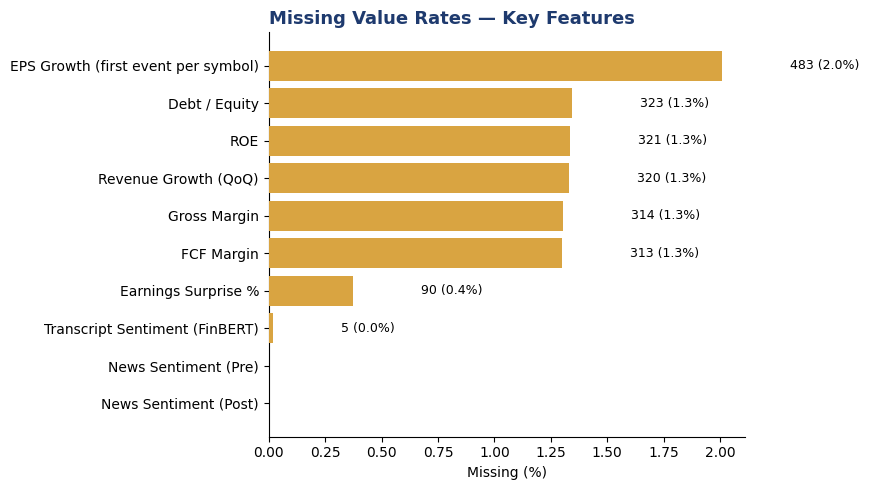

In [75]:
# Missingness of the key event-level features feeding each model family
key_miss_cols = {
    "eps_growth_qoq": "EPS Growth (first event per symbol)",
    "revenue_growth_qoq": "Revenue Growth (QoQ)",
    "gross_margin": "Gross Margin",
    "debt_to_equity": "Debt / Equity",
    "fcf_margin": "FCF Margin",
    "roe": "ROE",
    "surprisePercentage": "Earnings Surprise %",
    "pos_prob": "Transcript Sentiment (FinBERT)",
    "overall_sentiment_score_pre": "News Sentiment (Pre)",
    "overall_sentiment_score_post": "News Sentiment (Post)",
}

rows = []
for col, label in key_miss_cols.items():
    n_null = df_model[col].null_count()
    rows.append({"feature": label, "null_count": n_null, "null_pct": 100 * n_null / df_model.shape[0]})
null_df = pd.DataFrame(rows).sort_values("null_pct", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if p > 5 else (GOLD if p > 0 else GREEN) for p in null_df["null_pct"]]
ax.barh(null_df["feature"], null_df["null_pct"], color=colors, zorder=3)
for i, (_, row) in enumerate(null_df.iterrows()):
    if row["null_pct"] > 0:
        ax.text(row["null_pct"] + 0.3, i, f'{int(row["null_count"]):,} ({row["null_pct"]:.1f}%)',
                va="center", fontsize=9)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Value Rates — Key Features", fontsize=13, fontweight="bold", color=NAVY, loc="left")
sns.despine()
plt.tight_layout()
plt.show()

---
## 5. Outlier Detection (IQR Method)

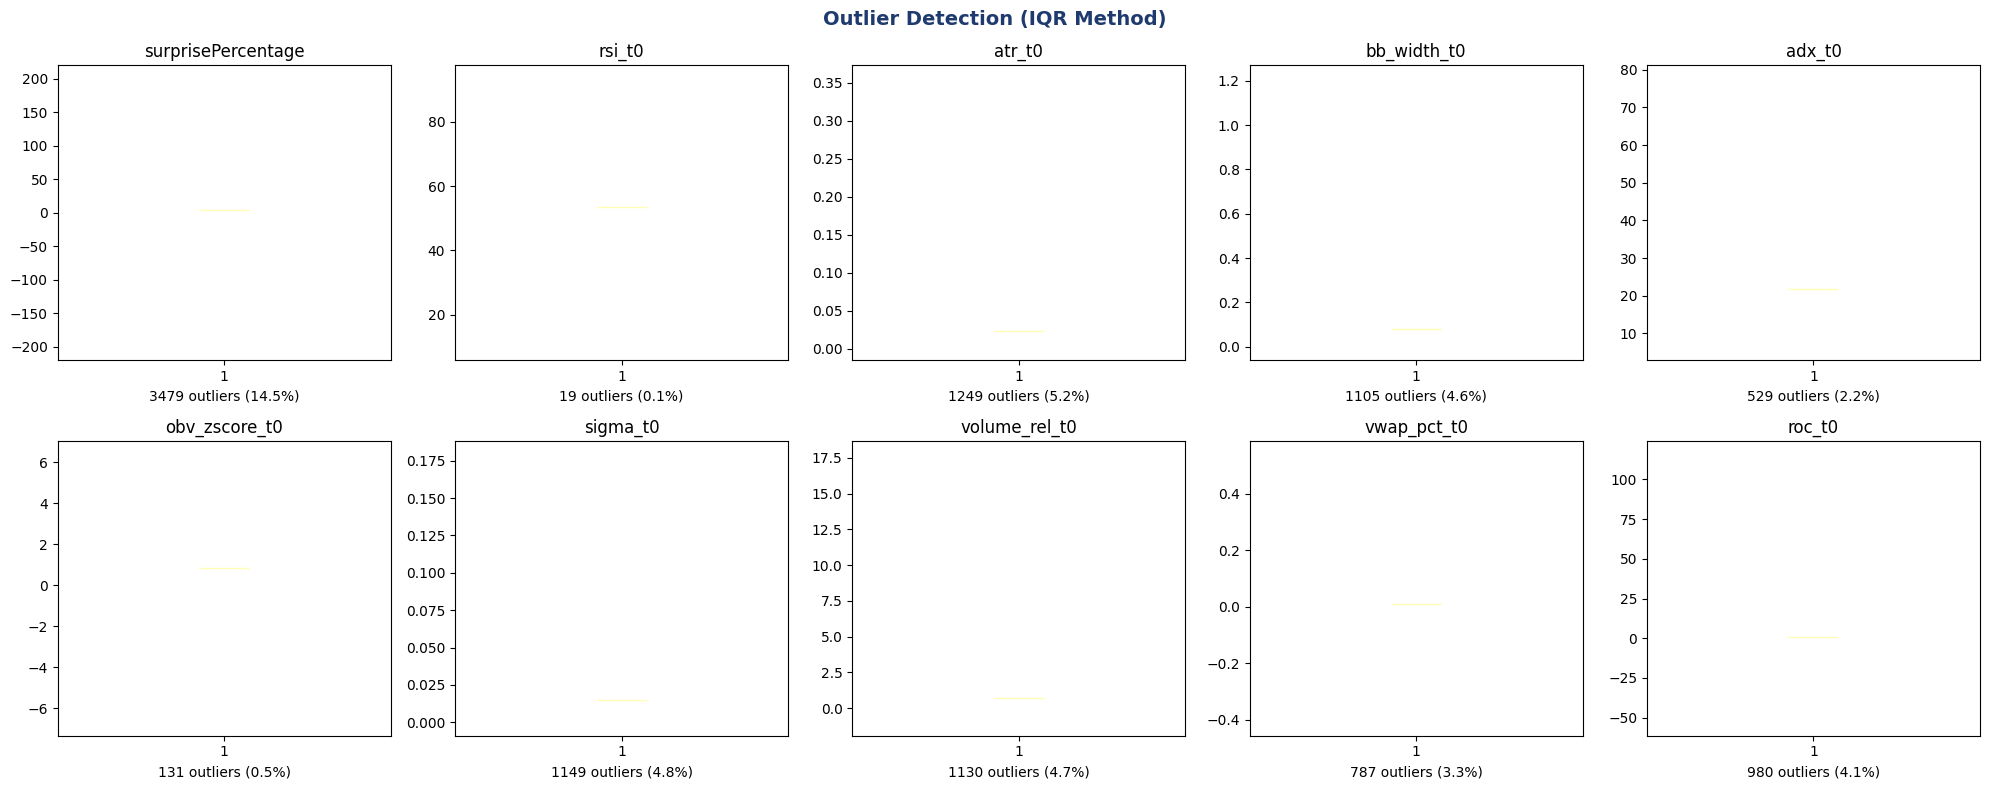

In [76]:
check_cols = ["surprisePercentage", "rsi_t0", "atr_t0", "bb_width_t0",
              "adx_t0", "obv_zscore_t0", "sigma_t0", "volume_rel_t0", "vwap_pct_t0", "roc_t0"]
check_cols = [c for c in check_cols if c in df_model.columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    vals = df_model[col].drop_nulls().to_list()
    axes[i].boxplot(vals)
    axes[i].set_title(col)

    q1, q3 = df_model[col].quantile(0.25), df_model[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = df_model.filter(
        (pl.col(col) < q1 - 1.5 * iqr) | (pl.col(col) > q3 + 1.5 * iqr)
    ).shape[0]
    axes[i].set_xlabel(f"{n_outliers} outliers ({100*n_outliers/df_model.shape[0]:.1f}%)")

plt.suptitle("Outlier Detection (IQR Method)", fontsize=14, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

In [77]:
# Flag inf values across all numeric pivoted columns (division-by-zero artifacts)
inf_rows = []
for c in pivoted_cols:
    n_inf = df_model.select(pl.col(c).is_infinite().sum())[0, 0]
    if n_inf > 0:
        inf_rows.append({"column": c, "inf_count": n_inf})

if inf_rows:
    print(f"{len(inf_rows)} columns with inf values:")
    print(pl.DataFrame(inf_rows).sort("inf_count", descending=True))
else:
    print("No inf values found in pivoted feature columns.")

No inf values found in pivoted feature columns.


---
## 6. Correlation & Relationship Analysis

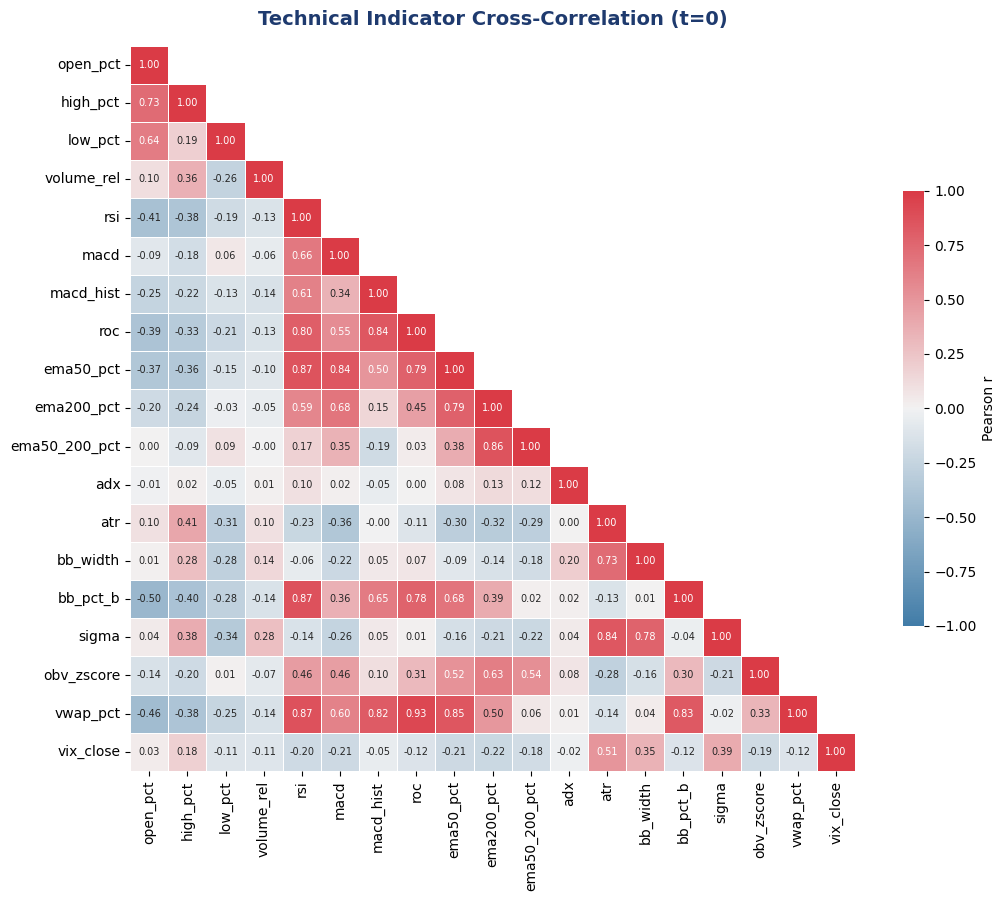

Highly correlated pairs (|r| > 0.85):
  rsi            <-> ema50_pct       r = +0.866
  rsi            <-> bb_pct_b        r = +0.872
  rsi            <-> vwap_pct        r = +0.868
  roc            <-> vwap_pct        r = +0.928
  ema200_pct     <-> ema50_200_pct   r = +0.863


In [78]:
tech_base_cols = ["open_pct", "high_pct", "low_pct", "volume_rel", "rsi", "macd", "macd_hist", "roc",
                   "ema50_pct", "ema200_pct", "ema50_200_pct", "adx", "atr", "bb_width", "bb_pct_b",
                   "sigma", "obv_zscore", "vwap_pct", "vix_close"]
corr_t0_cols = [f"{c}_t0" for c in tech_base_cols if f"{c}_t0" in df_model.columns]

corr_df = df_model.select(corr_t0_cols).to_pandas().dropna()
corr_matrix = corr_df.corr()
short_labels = [c.replace("_t0", "") for c in corr_t0_cols]
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap=sns.diverging_palette(240, 10, as_cmap=True),
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"},
            annot=True, fmt=".2f", annot_kws={"fontsize": 7}, ax=ax)
ax.set_title("Technical Indicator Cross-Correlation (t=0)", fontsize=14, fontweight="bold", color=NAVY, pad=15)
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.85):")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {corr_matrix.columns[i]:14s} <-> {corr_matrix.columns[j]:14s}  r = {r:+.3f}")

In [79]:
# Independent signals — max |r| with any other t0 indicator
corr_array = corr_matrix.to_numpy()
print("Independent signals at t0 (max |r| < 0.30 with all other indicators):")
for i, col in enumerate(corr_matrix.columns):
    max_r = max(abs(corr_array[i, j]) for j in range(len(corr_matrix.columns)) if j != i)
    if max_r < 0.30:
        print(f"  {col:14s} (max |r| = {max_r:.2f})")

# Redundancy across ALL time steps (not just t0)
exclude_base = ["symbol", "earnings_date", "target_return", "target_direction", "target_class",
                 "beat", "year", "month", "sector"]
all_feat = [c for c in df_model.columns if c not in exclude_base]
pdf_all = df_model.select(all_feat).to_pandas().select_dtypes(include=[np.number]).dropna()
corr_all = pdf_all.corr().to_numpy().copy()
np.fill_diagonal(corr_all, 0)
flagged = (np.abs(corr_all) > 0.95).any(axis=1).sum()

print(f"\nRedundancy across ALL {pdf_all.shape[1]} numeric features (any time step):")
print(f"  Features with |r| > 0.95 to another feature: {flagged}")
print(f"  Features retained after a 0.95 correlation filter: {pdf_all.shape[1] - flagged}")

Independent signals at t0 (max |r| < 0.30 with all other indicators):
  adx            (max |r| = 0.20)

Redundancy across ALL 269 numeric features (any time step):
  Features with |r| > 0.95 to another feature: 127
  Features retained after a 0.95 correlation filter: 142


---
## 7. Class Distribution Analysis

Overall beat/miss distribution:
shape: (3, 2)
┌──────┬───────┐
│ beat ┆ len   │
│ ---  ┆ ---   │
│ i8   ┆ u32   │
╞══════╪═══════╡
│ null ┆ 90    │
│ 0    ┆ 6337  │
│ 1    ┆ 17621 │
└──────┴───────┘
Overall beat rate: 73.5%


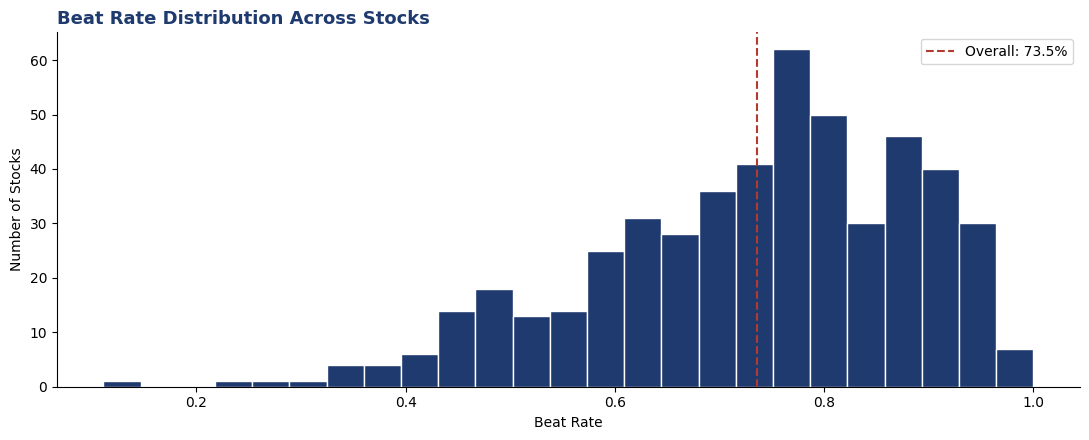

In [80]:
beat_dist = df_model.group_by("beat").len().sort("beat")
beat_rate = df_model["beat"].mean()
print("Overall beat/miss distribution:")
print(beat_dist)
print(f"Overall beat rate: {beat_rate:.1%}")

per_stock = df_model.group_by("symbol").agg([
    pl.col("beat").mean().alias("beat_rate"), pl.len().alias("events"),
]).sort("beat_rate")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(per_stock["beat_rate"].to_list(), bins=25, color=NAVY, edgecolor="white")
ax.axvline(x=beat_rate, color=RED, linestyle="--", label=f"Overall: {beat_rate:.1%}")
ax.set_title("Beat Rate Distribution Across Stocks", fontsize=13, fontweight="bold", color=NAVY, loc="left")
ax.set_xlabel("Beat Rate"); ax.set_ylabel("Number of Stocks")
ax.legend(); sns.despine()
plt.tight_layout()
plt.show()

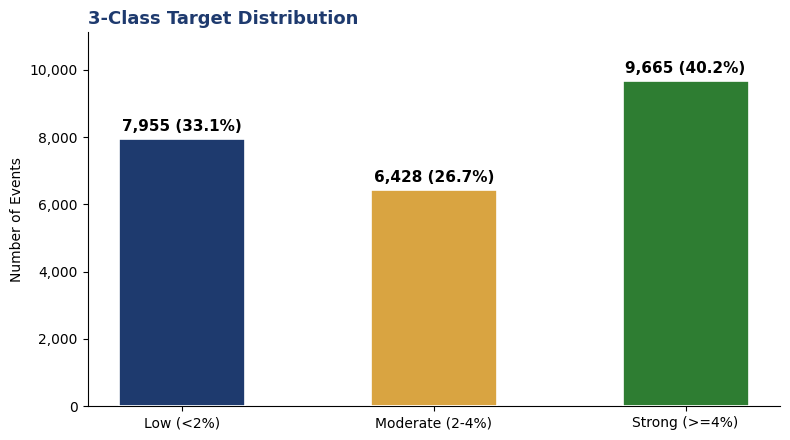

In [81]:
labels3 = {0: "Low (<2%)", 1: "Moderate (2-4%)", 2: "Strong (>=4%)"}
colors3 = {0: NAVY, 1: GOLD, 2: GREEN}
N = df_model.shape[0]
class_dist = df_model["target_class"].value_counts().sort("target_class")

counts = [class_dist.filter(pl.col("target_class") == i)["count"].item() for i in [0, 1, 2]]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([labels3[i] for i in [0, 1, 2]], counts, color=[colors3[i] for i in [0, 1, 2]],
              width=0.5, edgecolor="white", linewidth=1.2, zorder=3)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + N * 0.01,
            f"{count:,} ({100*count/N:.1f}%)", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Events")
ax.set_title("3-Class Target Distribution", fontsize=13, fontweight="bold", color=NAVY, loc="left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.margins(y=0.15); sns.despine()
plt.tight_layout()
plt.show()

Target return descriptive stats:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ target_return │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 24048.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 0.042991      │
│ std        ┆ 0.045487      │
│ min        ┆ -0.131541     │
│ 25%        ┆ 0.014795      │
│ 50%        ┆ 0.031805      │
│ 75%        ┆ 0.057408      │
│ max        ┆ 1.120253      │
└────────────┴───────────────┘

Percentiles:
0.014794945712215624 0.03180470359149634 0.05740773219592987 0.09101462416931883


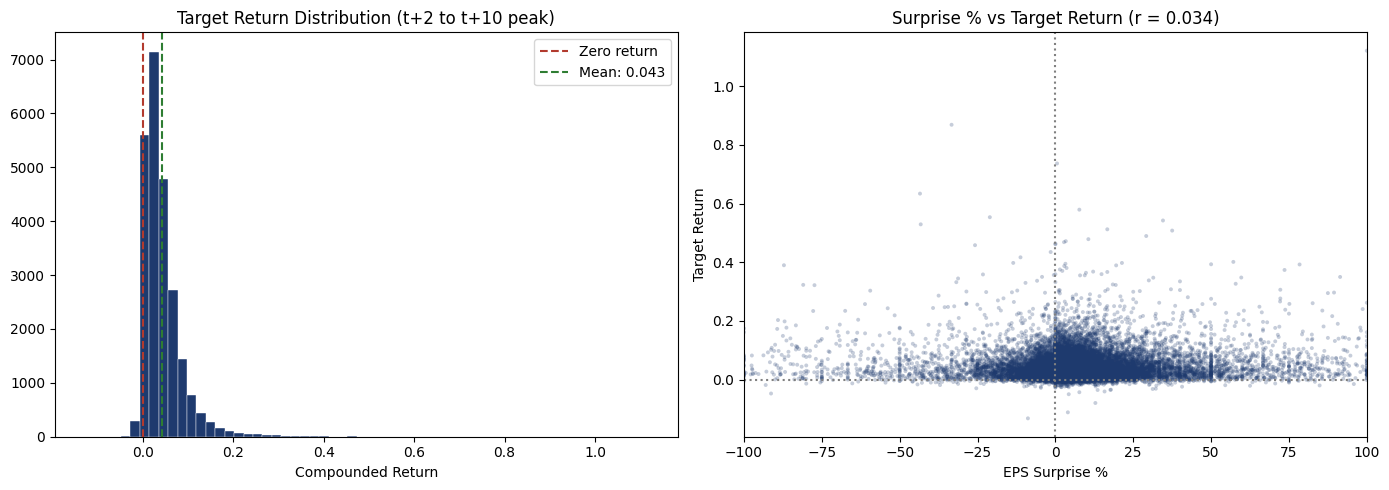

In [82]:
target_data = df_model["target_return"].drop_nulls()
print("Target return descriptive stats:")
print(df_model.select("target_return").describe())
print("\nPercentiles:")
print(df_model["target_return"].quantile(0.25), df_model["target_return"].quantile(0.5),
      df_model["target_return"].quantile(0.75), df_model["target_return"].quantile(0.9))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(target_data.to_list(), bins=60, color=NAVY, edgecolor="white", linewidth=0.3)
axes[0].axvline(x=0, color=RED, linestyle="--", label="Zero return")
axes[0].axvline(x=float(target_data.mean()), color=GREEN, linestyle="--",
                label=f"Mean: {float(target_data.mean()):.3f}")
axes[0].set_title("Target Return Distribution (t+2 to t+10 peak)")
axes[0].set_xlabel("Compounded Return"); axes[0].legend()

scatter = df_model.select("surprisePercentage", "target_return").drop_nulls()
axes[1].scatter(scatter["surprisePercentage"].to_list(), scatter["target_return"].to_list(),
                 alpha=0.25, s=8, color=NAVY, edgecolors="none")
r_val = np.corrcoef(scatter["surprisePercentage"].to_list(), scatter["target_return"].to_list())[0, 1]
axes[1].set_title(f"Surprise % vs Target Return (r = {r_val:.3f})")
axes[1].set_xlabel("EPS Surprise %"); axes[1].set_ylabel("Target Return")
axes[1].axhline(y=0, color="gray", linestyle=":"); axes[1].axvline(x=0, color="gray", linestyle=":")
axes[1].set_xlim(-100, 100)
plt.tight_layout()
plt.show()

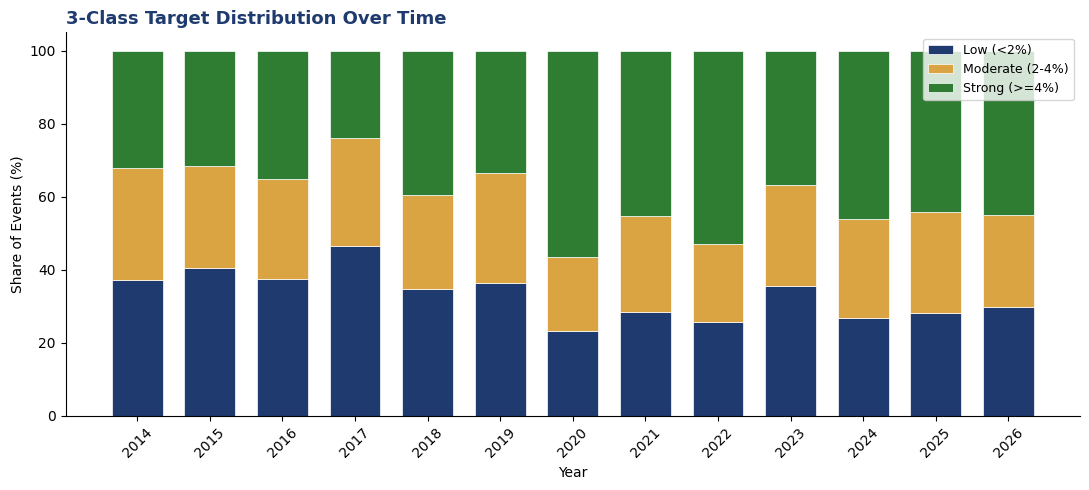

In [83]:
yearly_class = df_model.group_by(["year", "target_class"]).len().sort(["year", "target_class"])
yearly_pivot = yearly_class.to_pandas().pivot_table(index="year", columns="target_class", values="len", fill_value=0)
yearly_pct = yearly_pivot.div(yearly_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(yearly_pct))
for cls in [0, 1, 2]:
    vals = yearly_pct[cls].values if cls in yearly_pct.columns else np.zeros(len(yearly_pct))
    ax.bar(yearly_pct.index, vals, bottom=bottom, color=colors3[cls], label=labels3[cls],
           width=0.7, edgecolor="white", linewidth=0.5)
    bottom += vals
ax.set_xlabel("Year"); ax.set_ylabel("Share of Events (%)")
ax.set_title("3-Class Target Distribution Over Time", fontsize=13, fontweight="bold", color=NAVY, loc="left")
ax.legend(fontsize=9); ax.set_xticks(list(yearly_pct.index))
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

---
## 8. Target Variable Definition

The prediction target is the **peak compounded return from t+2 to t+10** (8 trading days) following each
earnings announcement. t+1 is excluded because it captures the immediate gap reaction, which is priced in
within hours — PEAD theory concerns the slower drift that follows as the market underreacts to the surprise.

- **Regression target:** `target_return` - continuous peak compounded return
- **Classification targets:**
  - `target_class` - 3-class bucketing: Low (<2%), Moderate (2-4%), Strong (>=4%)

Both are computed upstream from daily prices before pivoting, so there is no leakage from future prices into
the feature window (t-10 to t0).

---
## 9. PEAD Signal Analysis

This is the central hypothesis test for the project: do stocks that beat earnings estimates keep drifting up
after the announcement, and do misses keep drifting down?

In [84]:
df_ohlcv = pl.read_parquet("../ingestion/data/backup/ohlcv_delta_backup.parquet")
print(f"OHLCV loaded: {df_ohlcv.shape}")

def compute_drift_profile(df_model, df_ohlcv):
    """Average cumulative return from t-9 to t+10 (entry = close at t-1), split Beat vs Miss."""
    beat_profiles, miss_profiles = [], []
    for symbol in df_model["symbol"].unique().to_list():
        sym_daily = df_ohlcv.filter(pl.col("symbol") == symbol).sort("date")
        dates = sym_daily["date"].to_list()
        closes = sym_daily["close"].to_numpy()

        sym_events = df_model.filter(pl.col("symbol") == symbol)
        for row in sym_events.iter_rows(named=True):
            if row["beat"] is None:
                continue  # surprisePercentage missing for this event -> beat/miss undefined
            earn_date = row["earnings_date"]
            t0 = bisect_left(dates, earn_date)
            if t0 < 10 or t0 + 10 >= len(dates) or dates[t0] != earn_date:
                continue
            rets = [(closes[t0 + d] - closes[t0 - 1]) / closes[t0 - 1] for d in range(-9, 11)]
            (beat_profiles if row["beat"] == 1 else miss_profiles).append(np.array(rets))
    return np.array(beat_profiles), np.array(miss_profiles)

beat_p, miss_p = compute_drift_profile(df_model, df_ohlcv)
print(f"Beat profiles: {len(beat_p):,}, Miss profiles: {len(miss_p):,}")

OHLCV loaded: (4385666, 7)
Beat profiles: 17,621, Miss profiles: 6,337


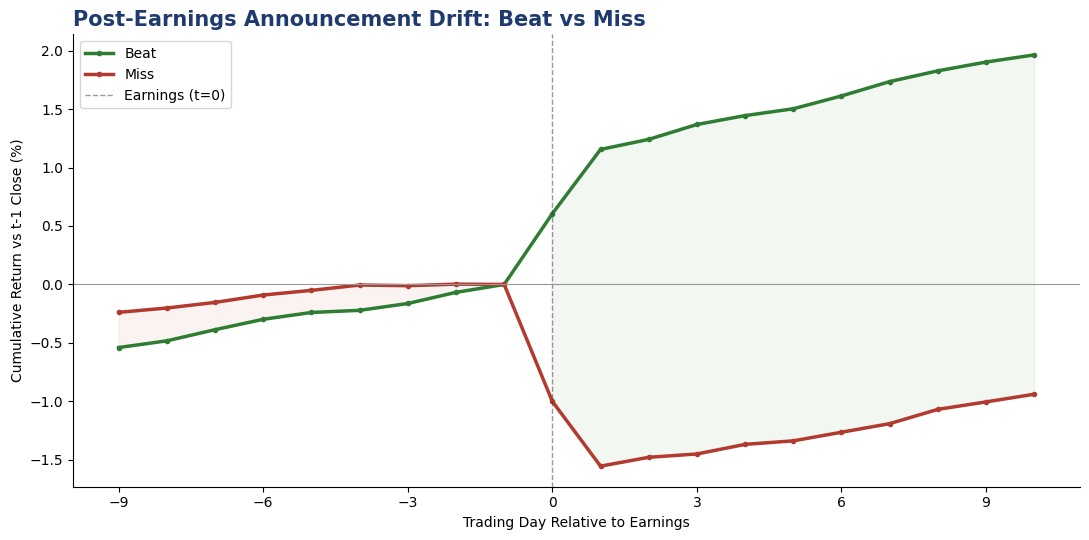

Beat t+1: +1.15%   Beat t+10: +1.96%
Miss t+1: -1.55%   Miss t+10: -0.94%


In [85]:
beat_mean = np.mean(beat_p, axis=0) * 100
miss_mean = np.mean(miss_p, axis=0) * 100
time_labels = list(range(-9, 11))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(time_labels, beat_mean, color=GREEN, linewidth=2.5, label="Beat", marker="o", markersize=3)
ax.plot(time_labels, miss_mean, color=RED, linewidth=2.5, label="Miss", marker="o", markersize=3)
ax.axvline(x=0, color="#333", linestyle="--", linewidth=1, alpha=0.5, label="Earnings (t=0)")
ax.fill_between(time_labels, beat_mean, miss_mean, where=(beat_mean > miss_mean), color=GREEN, alpha=0.06)
ax.fill_between(time_labels, beat_mean, miss_mean, where=(beat_mean <= miss_mean), color=RED, alpha=0.06)
ax.axhline(y=0, color="#999", linewidth=0.8)
ax.set_xlabel("Trading Day Relative to Earnings"); ax.set_ylabel("Cumulative Return vs t-1 Close (%)")
ax.set_title("Post-Earnings Announcement Drift: Beat vs Miss", fontsize=15, fontweight="bold", color=NAVY, loc="left")
ax.legend(fontsize=10, loc="upper left"); ax.set_xticks(range(-9, 11, 3))
sns.despine()
plt.tight_layout()
plt.show()

print(f"Beat t+1: {beat_mean[10]:+.2f}%   Beat t+10: {beat_mean[-1]:+.2f}%")
print(f"Miss t+1: {miss_mean[10]:+.2f}%   Miss t+10: {miss_mean[-1]:+.2f}%")

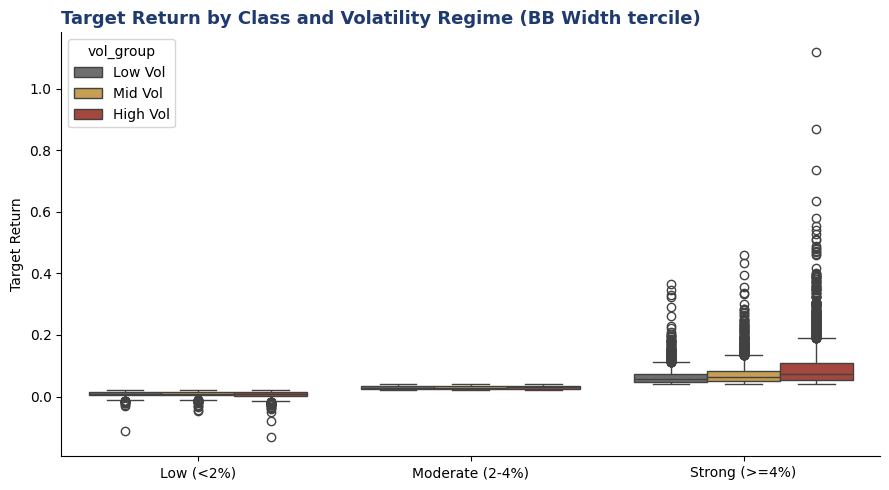

In [86]:
# Volatility regime vs magnitude of drift
df_model = df_model.with_columns([
    pl.col("atr_t0").rank().alias("atr_rank"),
    pl.col("vix_close_t0").rank().alias("vix_rank"),
    pl.col("sigma_t0").rank().alias("sigma_rank"),
])
df_model = df_model.with_columns(
    ((pl.col("atr_rank") + pl.col("vix_rank") + pl.col("sigma_rank")) / 3).alias("vol_score")
)

pdf_vol = df_model.select(["target_class", "target_return", "bb_width_t0"]).to_pandas().dropna()
pdf_vol["vol_group"] = pd.qcut(pdf_vol["bb_width_t0"], 3, labels=["Low Vol", "Mid Vol", "High Vol"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=pdf_vol, x="target_class", y="target_return", hue="vol_group", ax=ax,
            palette=[MUTED, GOLD, RED])
ax.set_xticklabels([labels3[i] for i in [0, 1, 2]])
ax.set_title("Target Return by Class and Volatility Regime (BB Width tercile)",
             fontsize=13, fontweight="bold", color=NAVY, loc="left")
ax.set_xlabel(""); ax.set_ylabel("Target Return")
sns.despine()
plt.tight_layout()
plt.show()

shape: (12, 4)
┌────────────────────────┬────────┬───────────┬───────────┐
│ sector                 ┆ events ┆ beat_rate ┆ avg_drift │
│ ---                    ┆ ---    ┆ ---       ┆ ---       │
│ str                    ┆ u32    ┆ f64       ┆ f64       │
╞════════════════════════╪════════╪═══════════╪═══════════╡
│ Technology             ┆ 3863   ┆ 0.84201   ┆ 0.050047  │
│ Industrials            ┆ 3515   ┆ 0.760684  ┆ 0.042118  │
│ Financial Services     ┆ 3372   ┆ 0.735058  ┆ 0.041449  │
│ Healthcare             ┆ 2845   ┆ 0.809775  ┆ 0.040532  │
│ Consumer Cyclical      ┆ 2583   ┆ 0.703082  ┆ 0.047012  │
│ Consumer Defensive     ┆ 1641   ┆ 0.716993  ┆ 0.03204   │
│ Real Estate            ┆ 1521   ┆ 0.575937  ┆ 0.03742   │
│ Utilities              ┆ 1506   ┆ 0.630565  ┆ 0.031612  │
│ Communication Services ┆ 1114   ┆ 0.703237  ┆ 0.047469  │
│ Energy                 ┆ 1017   ┆ 0.65893   ┆ 0.054766  │
│ Basic Materials        ┆ 952    ┆ 0.666667  ┆ 0.04881   │
│ Unknown                

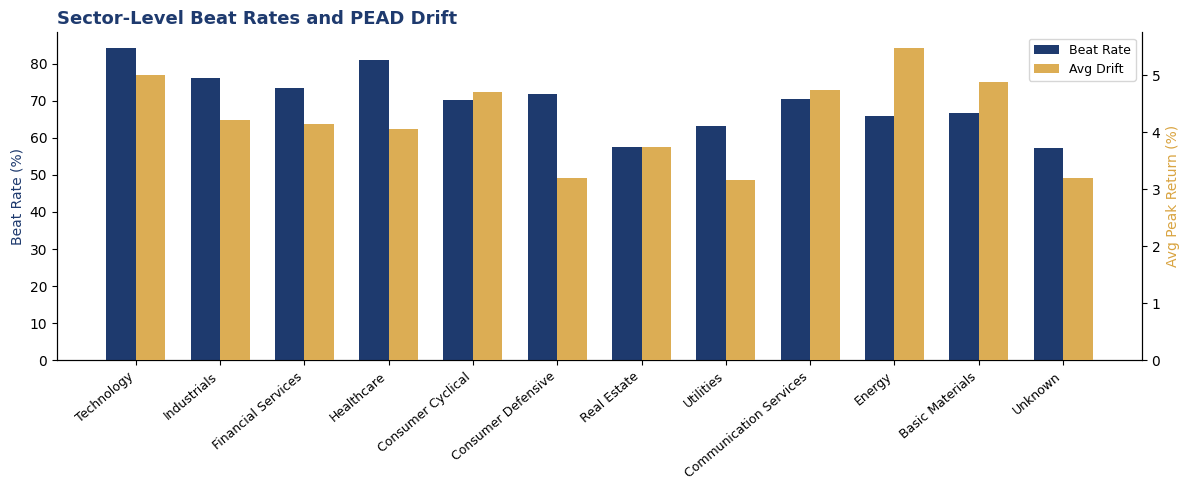

In [87]:
# Sector-level PEAD behaviour
sector_analysis = df_model.filter(pl.col("sector").is_not_null()).group_by("sector").agg([
    pl.len().alias("events"),
    pl.col("beat").mean().alias("beat_rate"),
    pl.col("target_return").mean().alias("avg_drift"),
]).sort("events", descending=True)
sector_pd = sector_analysis.to_pandas()
print(sector_analysis)

fig, ax1 = plt.subplots(figsize=(12, 5))
x = range(len(sector_pd)); w = 0.35
ax1.bar([i - w/2 for i in x], sector_pd["beat_rate"] * 100, w, color=NAVY, label="Beat Rate", zorder=3)
ax2 = ax1.twinx()
ax2.bar([i + w/2 for i in x], sector_pd["avg_drift"] * 100, w, color=GOLD, label="Avg Drift", zorder=3, alpha=0.9)
ax1.set_xticks(list(x)); ax1.set_xticklabels(sector_pd["sector"].values, rotation=40, ha="right", fontsize=9)
ax1.set_ylabel("Beat Rate (%)", color=NAVY); ax2.set_ylabel("Avg Peak Return (%)", color=GOLD)
ax1.set_title("Sector-Level Beat Rates and PEAD Drift", fontsize=13, fontweight="bold", color=NAVY, loc="left")
lines1, l1 = ax1.get_legend_handles_labels(); lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc="upper right", fontsize=9)
sns.despine(right=False)
plt.tight_layout()
plt.show()

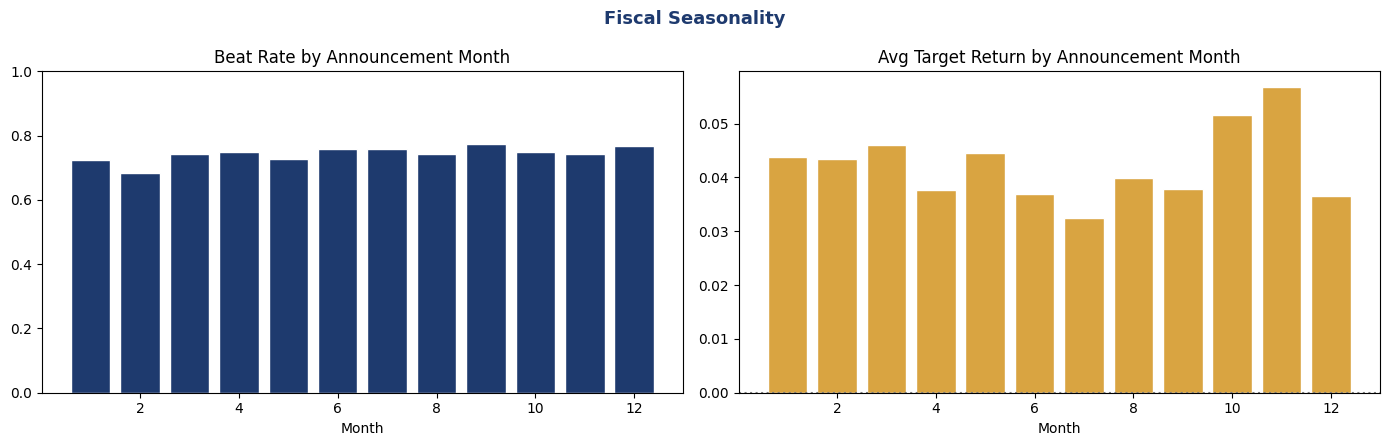

In [88]:
# Fiscal seasonality
monthly = df_model.group_by("month").agg([
    pl.len().alias("count"), pl.col("beat").mean().alias("beat_rate"),
    pl.col("target_return").mean().alias("avg_target_return"),
]).sort("month")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(monthly["month"].to_list(), monthly["beat_rate"].to_list(), color=NAVY, edgecolor="white")
axes[0].set_title("Beat Rate by Announcement Month"); axes[0].set_ylim(0, 1); axes[0].set_xlabel("Month")
axes[1].bar(monthly["month"].to_list(), monthly["avg_target_return"].to_list(), color=GOLD, edgecolor="white")
axes[1].axhline(y=0, color="gray", linestyle=":")
axes[1].set_title("Avg Target Return by Announcement Month"); axes[1].set_xlabel("Month")
plt.suptitle("Fiscal Seasonality", fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

---
## 10. Feature Importance — Predictive Signal Assessment

In [89]:
# Beat vs miss mean comparison for t0 features
compare_cols = t0_cols + ["surprise", "surprisePercentage", "pos_prob", "neg_prob",
                           "overall_sentiment_score_pre"]
compare_cols = [c for c in compare_cols if c in df_model.columns]

beat_means = df_model.filter(pl.col("beat") == 1).select(compare_cols).mean()
miss_means = df_model.filter(pl.col("beat") == 0).select(compare_cols).mean()

rows = []
for col in compare_cols:
    b, m = beat_means[col][0], miss_means[col][0]
    pct = 100 * (b - m) / abs(m) if m and m != 0 and b is not None else None
    rows.append({"feature": col, "beat_mean": round(b, 4) if b is not None else None,
                 "miss_mean": round(m, 4) if m is not None else None,
                 "pct_diff": round(pct, 1) if pct is not None else None})

print("Feature means: Beat vs Miss (sorted by % difference)")
print(pl.DataFrame(rows).sort("pct_diff", descending=True, nulls_last=True))

Feature means: Beat vs Miss (sorted by % difference)
shape: (24, 4)
┌────────────────────┬───────────┬───────────┬──────────┐
│ feature            ┆ beat_mean ┆ miss_mean ┆ pct_diff │
│ ---                ┆ ---       ┆ ---       ┆ ---      │
│ str                ┆ f64       ┆ f64       ┆ f64      │
╞════════════════════╪═══════════╪═══════════╪══════════╡
│ macd_t0            ┆ 0.0037    ┆ -0.0001   ┆ 2909.5   │
│ ema50_pct_t0       ┆ 0.0199    ┆ -0.004    ┆ 598.7    │
│ vwap_pct_t0        ┆ 0.0133    ┆ -0.0032   ┆ 522.4    │
│ roc_t0             ┆ 1.5057    ┆ -0.4226   ┆ 456.3    │
│ macd_hist_t0       ┆ 0.0007    ┆ -0.0003   ┆ 329.2    │
│ ema200_pct_t0      ┆ 0.0607    ┆ 0.0173    ┆ 251.2    │
│ surprise           ┆ 0.1629    ┆ -0.1077   ┆ 251.2    │
│ surprisePercentage ┆ 18.0935   ┆ -17.1795  ┆ 205.3    │
│ …                  ┆ …         ┆ …         ┆ …        │
│ low_pct_t0         ┆ -0.0203   ┆ -0.0197   ┆ -2.7     │
│ bb_width_t0        ┆ 0.0959    ┆ 0.0989    ┆ -3.0     │
│ si

In [90]:
from sklearn.feature_selection import mutual_info_classif

exclude = ["symbol", "earnings_date", "target_return", "target_direction", "target_class",
           "beat", "year", "month", "sector"]
feature_cols = [c for c in df_model.columns if c not in exclude]

df_pd = df_model.select(feature_cols + ["target_direction"]).to_pandas()
df_pd = df_pd.fillna(df_pd.median(numeric_only=True))
df_pd = df_pd.dropna(subset=["target_direction"])

X = df_pd[feature_cols].select_dtypes(include=[np.number])
y = df_pd["target_direction"]
print(f"Rows used: {len(X):,}, features: {X.shape[1]}")

mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\nTop 20 features by mutual information with target_direction:")
print(mi_series.head(20))

Rows used: 24,048, features: 273

Top 20 features by mutual information with target_direction:
max_day                         0.036232
car_t2_t10                      0.027683
vix_close_t-6                   0.025193
vix_close_t-5                   0.025082
vix_close_t-7                   0.025001
vix_close_t-8                   0.024958
vix_close_t-2                   0.024945
vix_close_t-4                   0.024074
vix_close_t-1                   0.023804
vix_rank                        0.023560
vix_close_t+1                   0.023427
vix_close_t-3                   0.023235
vix_close_t0                    0.023185
vix_close_t-10                  0.022931
vix_close_t-9                   0.022822
min_day                         0.014864
overall_sentiment_score_post    0.003510
ema200_pct_t-3                  0.003400
gross_margin                    0.003283
atr_t-4                         0.003280
dtype: float64


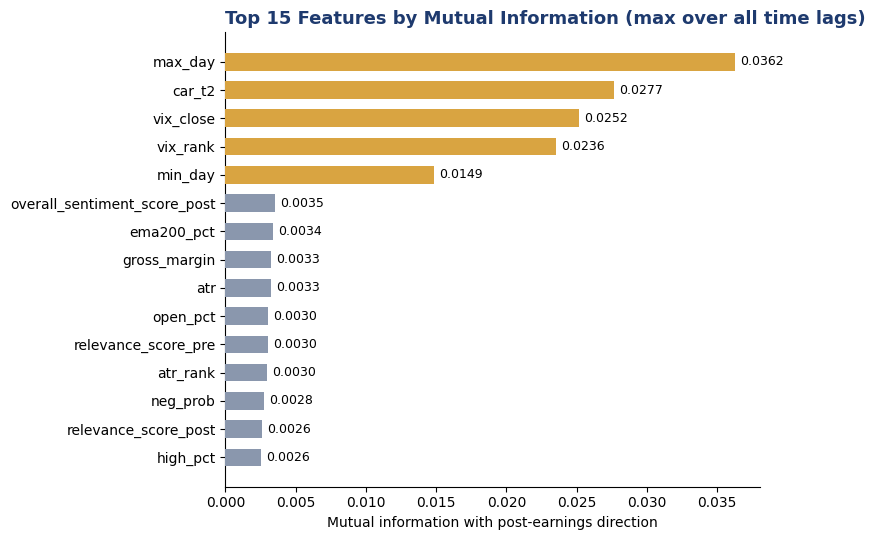

In [51]:
# Collapse to one score per base indicator (max across its time lags), plot top 15
def get_base_indicator(col_name):
    return re.sub(r"_t[+-]?\d+$", "", col_name)

mi_df = mi_series.reset_index()
mi_df.columns = ["feature", "mi_score"]
mi_df["base_indicator"] = mi_df["feature"].apply(get_base_indicator)
mi_by_indicator = mi_df.groupby("base_indicator")["mi_score"].max().sort_values(ascending=False)

plot_df = mi_by_indicator.reset_index().head(15)
plot_df.columns = ["indicator", "mi_score"]

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [GOLD if i < 5 else MUTED for i in range(len(plot_df))]
bars = ax.barh(plot_df["indicator"], plot_df["mi_score"], color=colors, height=0.62, zorder=3)
ax.invert_yaxis()
for b, v in zip(bars, plot_df["mi_score"]):
    ax.text(v + plot_df["mi_score"].max() * 0.01, b.get_y() + b.get_height()/2, f"{v:.4f}",
            va="center", fontsize=9)
ax.set_xlabel("Mutual information with post-earnings direction")
ax.set_title("Top 15 Features by Mutual Information (max over all time lags)",
             fontsize=13, fontweight="bold", color=NAVY, loc="left")
sns.despine()
plt.tight_layout()
plt.show()

family
Volatility              0.007698
Price / trend           0.002560
Momentum                0.002027
Transcript Sentiment    0.001713
Volume                  0.001658
News Sentiment          0.001125
Fundamentals            0.001082
Name: mi_score, dtype: float64


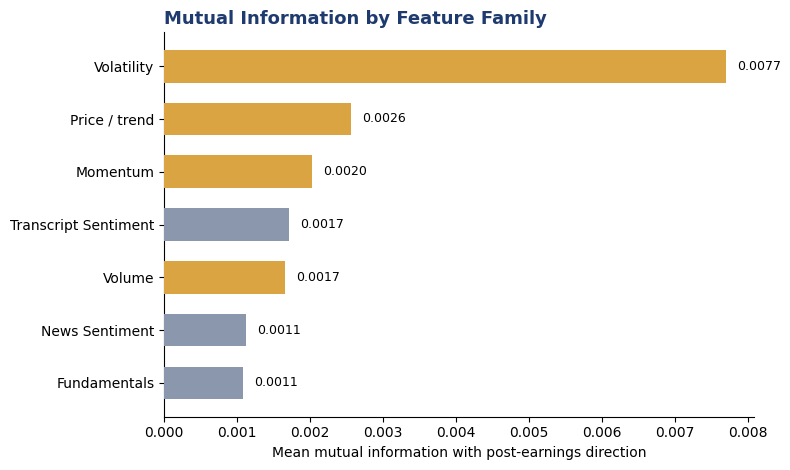

In [52]:
# Aggregate MI by feature family
FAMILY_RULES = [
    ("Volatility",    ["bb_width", "bb_pct_b", "atr", "sigma", "vix"]),
    ("Price / trend", ["high_pct", "low_pct", "open_pct", "vwap", "ema"]),
    ("Volume",        ["obv", "volume_rel"]),
    ("Momentum",      ["macd", "rsi", "adx", "roc"]),
    ("Transcript Sentiment", ["pos_prob", "neg_prob"]),
    ("News Sentiment", ["sentiment_score"]),
    ("Fundamentals",  ["eps", "revenue", "margin", "roe", "debt", "fcf", "growth", "surprise"]),
]

def to_family(name):
    n = name.lower()
    for fam, keys in FAMILY_RULES:
        if any(k in n for k in keys):
            return fam
    return "Other"

fam_df = mi_by_indicator.reset_index()
fam_df.columns = ["indicator", "mi_score"]
fam_df["family"] = fam_df["indicator"].apply(to_family)
fam_mi = fam_df.groupby("family")["mi_score"].mean().sort_values(ascending=False)
fam_mi = fam_mi.drop(labels=["Other"], errors="ignore")
print(fam_mi)

TECHNICAL = {"Volatility", "Price / trend", "Volume", "Momentum"}
colors = [GOLD if fam in TECHNICAL else MUTED for fam in fam_mi.index]
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(fam_mi.index, fam_mi.values, color=colors, height=0.62, zorder=3)
ax.invert_yaxis()
for b, v in zip(bars, fam_mi.values):
    ax.text(v + fam_mi.max() * 0.02, b.get_y() + b.get_height()/2, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlabel("Mean mutual information with post-earnings direction")
ax.set_title("Mutual Information by Feature Family", fontsize=13, fontweight="bold", color=NAVY, loc="left")
sns.despine()
plt.tight_layout()
plt.show()

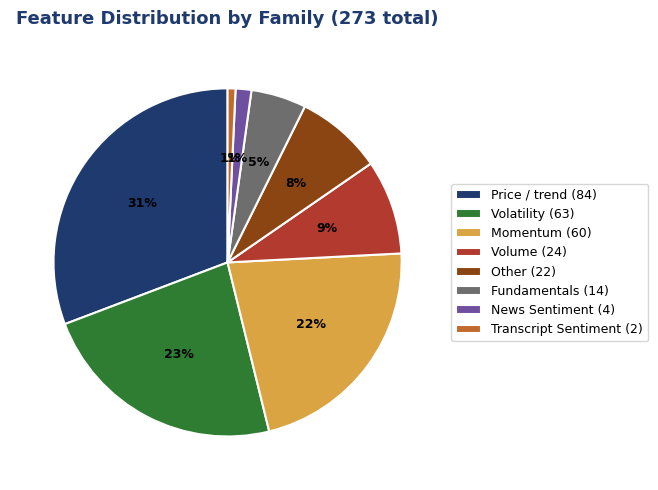

In [54]:
# Overall feature composition (how many raw columns belong to each family)
families = {}
for c in feature_cols:
    families[to_family(get_base_indicator(c))] = families.get(to_family(get_base_indicator(c)), 0) + 1

fam_items = sorted(families.items(), key=lambda x: -x[1])
fam_colors_list = [NAVY, GREEN, GOLD, RED, "#8B4513", MUTED, "#6f4f9f", "#c26a2c"]

fig, ax = plt.subplots(figsize=(8, 5))
names = [n for n, _ in fam_items]; counts = [c for _, c in fam_items]
wedges, texts, autotexts = ax.pie(counts, autopct="%1.0f%%", startangle=90,
    colors=fam_colors_list[:len(fam_items)], wedgeprops={"edgecolor": "white", "linewidth": 1.5})
for t in autotexts:
    t.set_fontsize(9); t.set_fontweight("bold")
ax.legend(wedges, [f"{n} ({c})" for n, c in zip(names, counts)], loc="center left",
          bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title(f"Feature Distribution by Family ({sum(counts)} total)",
             fontsize=13, fontweight="bold", color=NAVY, pad=15)
plt.tight_layout()
plt.show()

---
## 11. Transcript & Management Commentary Analysis

The technical/fundamental features above summarize *what* happened; this section looks at earnings-call
transcripts to understand *what management said* and whether tone carries any additional signal.

Quarter-level transcript rows: 23,313
Symbols: 500
Quarters with no transcript turns: 209
Avg turns/quarter: 65.7   Median: 63.0


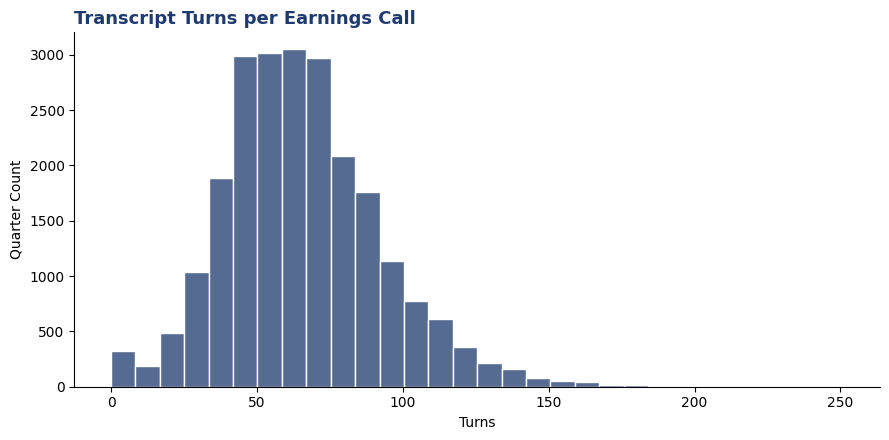

In [55]:
df_tx = pl.read_parquet("../ingestion/data/backup/temp_transcripts.parquet")
tx_over = df_tx.with_columns(pl.col("transcript").list.len().alias("turn_count"))

print(f"Quarter-level transcript rows: {tx_over.height:,}")
print(f"Symbols: {tx_over['symbol'].n_unique():,}")
print(f"Quarters with no transcript turns: {tx_over.filter(pl.col('turn_count') == 0).height:,}")
print(f"Avg turns/quarter: {tx_over['turn_count'].mean():.1f}   Median: {tx_over['turn_count'].median():.1f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(tx_over["turn_count"].to_list(), bins=30, color=NAVY, ax=ax)
ax.set_title("Transcript Turns per Earnings Call", fontsize=13, fontweight="bold", color=NAVY, loc="left")
ax.set_xlabel("Turns"); ax.set_ylabel("Quarter Count")
sns.despine()
plt.tight_layout()
plt.show()

shape: (6, 4)
┌───────────┬────────┬─────────────┬───────────────┐
│ role      ┆ turns  ┆ total_words ┆ avg_sentiment │
│ ---       ┆ ---    ┆ ---         ┆ ---           │
│ str       ┆ u32    ┆ u32         ┆ f64           │
╞═══════════╪════════╪═════════════╪═══════════════╡
│ Executive ┆ 503296 ┆ 93075916    ┆ 0.363422      │
│ Finance   ┆ 180932 ┆ 39192538    ┆ 0.307105      │
│ Analyst   ┆ 531182 ┆ 29044932    ┆ 0.130995      │
│ Other     ┆ 50490  ┆ 8209134     ┆ 0.346808      │
│ Operator  ┆ 240222 ┆ 4918244     ┆ 0.005182      │
│ IR        ┆ 22385  ┆ 2475024     ┆ 0.108139      │
└───────────┴────────┴─────────────┴───────────────┘


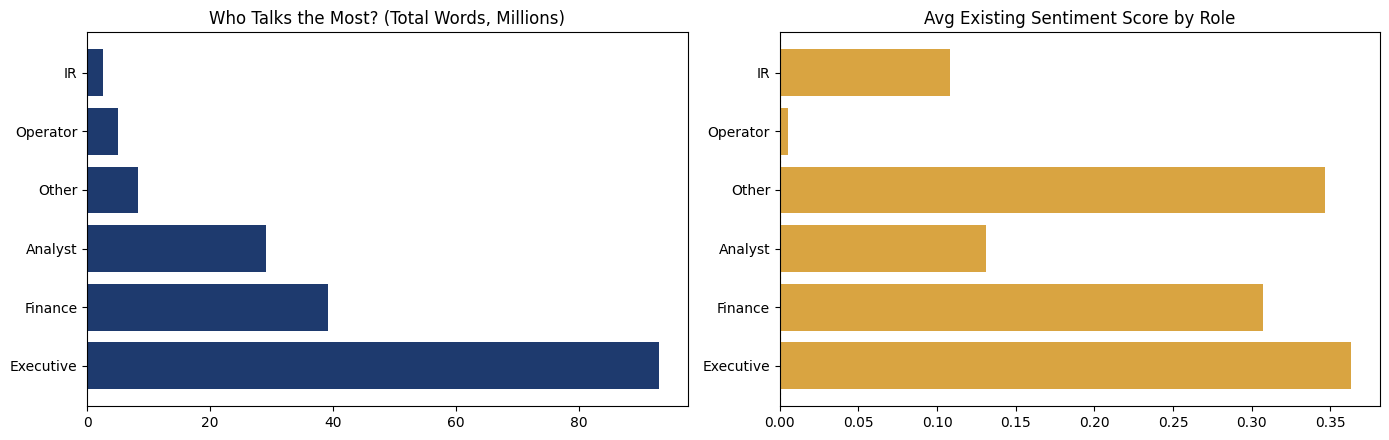

In [56]:
# Explode to turn level and classify speaker role
tx_turns = (
    tx_over.select(["symbol", "reportedDate", "transcript"])
    .explode("transcript")
    .unnest("transcript")
    .with_columns([
        pl.col("speaker").fill_null("Unknown").str.strip_chars().alias("speaker"),
        pl.col("title").fill_null("Unknown").str.strip_chars().alias("title"),
        pl.col("content").fill_null("").str.strip_chars().alias("content"),
        pl.col("sentiment").cast(pl.Float64, strict=False).alias("sentiment_score"),
    ])
    .with_columns(pl.col("content").str.count_matches(r"\S+").alias("content_words"))
)

role_expr = (
    pl.when(pl.col("speaker").str.to_lowercase() == "operator").then(pl.lit("Operator"))
    .when(pl.col("title").str.to_lowercase().str.contains("analyst|research")).then(pl.lit("Analyst"))
    .when(pl.col("title").str.to_lowercase().str.contains("chief executive|ceo|president")).then(pl.lit("Executive"))
    .when(pl.col("title").str.to_lowercase().str.contains("chief financial|cfo|finance")).then(pl.lit("Finance"))
    .when(pl.col("title").str.to_lowercase().str.contains("investor relation")).then(pl.lit("IR"))
    .otherwise(pl.lit("Other"))
)
tx_turns = tx_turns.with_columns(role_expr.alias("role"))

role_summary = tx_turns.group_by("role").agg([
    pl.len().alias("turns"), pl.col("content_words").sum().alias("total_words"),
    pl.col("sentiment_score").mean().alias("avg_sentiment"),
]).sort("total_words", descending=True)
print(role_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
rp = role_summary.to_pandas()
axes[0].barh(rp["role"], rp["total_words"] / 1e6, color=NAVY)
axes[0].set_title("Who Talks the Most? (Total Words, Millions)")
axes[1].barh(rp["role"], rp["avg_sentiment"], color=GOLD)
axes[1].set_title("Avg Existing Sentiment Score by Role")
axes[1].axvline(x=0, color="gray", linestyle=":")
plt.tight_layout()
plt.show()

Matched events: 22,908
r (management sentiment vs target_return) = 0.0284


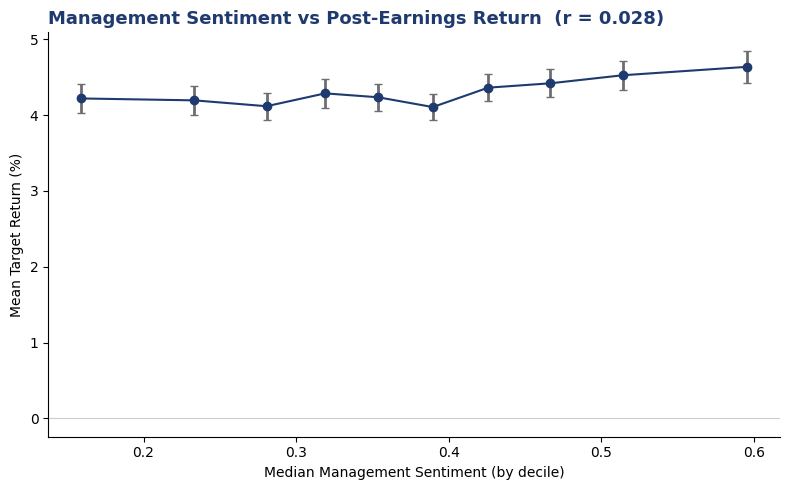

In [57]:
# Management sentiment (Executive + Finance) vs post-earnings return
mgmt_sentiment = (
    tx_turns.filter(pl.col("role").is_in(["Executive", "Finance"]))
    .group_by("symbol", "reportedDate")
    .agg(pl.col("sentiment_score").mean().alias("mgmt_sentiment"), pl.len().alias("mgmt_turns"))
)

merged_sentiment = df_model.select(["symbol", "earnings_date", "target_return"]).join(
    mgmt_sentiment.rename({"reportedDate": "earnings_date"}),
    on=["symbol", "earnings_date"], how="inner",
).drop_nulls(["mgmt_sentiment", "target_return"])

x_all = merged_sentiment["mgmt_sentiment"].to_numpy()
y_all = merged_sentiment["target_return"].to_numpy()
r = np.corrcoef(x_all, y_all)[0, 1]
print(f"Matched events: {merged_sentiment.height:,}")
print(f"r (management sentiment vs target_return) = {r:.4f}")

df_bin = merged_sentiment.to_pandas()
df_bin["decile"] = pd.qcut(df_bin["mgmt_sentiment"], 10, labels=False, duplicates="drop")
binned = df_bin.groupby("decile").agg(
    sentiment_mid=("mgmt_sentiment", "median"), return_mean=("target_return", "mean"),
    return_sem=("target_return", "sem"),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(binned["sentiment_mid"], binned["return_mean"] * 100, yerr=binned["return_sem"] * 100 * 1.96,
            fmt="o-", color=NAVY, ecolor=MUTED, elinewidth=2, capsize=3, markersize=6)
ax.axhline(0, color="#ccc", linewidth=0.8)
ax.set_xlabel("Median Management Sentiment (by decile)"); ax.set_ylabel("Mean Target Return (%)")
ax.set_title(f"Management Sentiment vs Post-Earnings Return  (r = {r:.3f})",
             fontsize=13, fontweight="bold", color=NAVY, loc="left")
sns.despine()
plt.tight_layout()
plt.show()

Prepared remarks vs Q&A word share:
shape: (2, 2)
┌──────────────────┬───────────┐
│ section          ┆ words     │
│ ---              ┆ ---       │
│ str              ┆ u32       │
╞══════════════════╪═══════════╡
│ Q&A              ┆ 117982437 │
│ Prepared Remarks ┆ 58933351  │
└──────────────────┴───────────┘

Boilerplate content: 9.07% of all transcript words


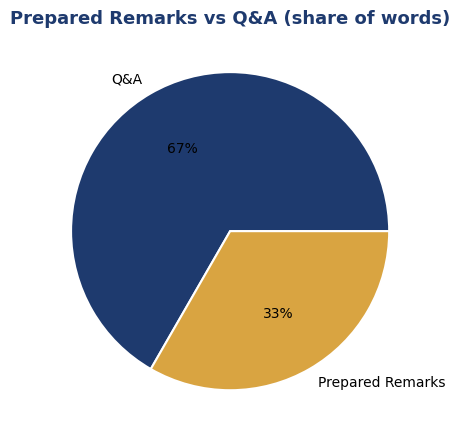

In [58]:
# Prepared remarks vs Q&A split (position-based, vectorized) and boilerplate content
tx_turns = tx_turns.with_columns(
    (pl.col("content_words").cum_sum().over(["symbol", "reportedDate"])
     / pl.col("content_words").sum().over(["symbol", "reportedDate"])).alias("cum_word_frac")
)
tx_turns = tx_turns.with_columns(
    pl.when(pl.col("cum_word_frac") <= 0.4).then(pl.lit("Prepared Remarks")).otherwise(pl.lit("Q&A")).alias("section")
)

section_summary = tx_turns.group_by("section").agg(pl.col("content_words").sum().alias("words"))
print("Prepared remarks vs Q&A word share:")
print(section_summary)

bp_patterns = ["forward-looking statement", "safe harbor", "actual results may differ", "non-gaap",
               "this call is being recorded", "regulation fd"]
bp_pattern_re = "(?i)" + "|".join(bp_patterns)
tx_turns = tx_turns.with_columns(pl.col("content").str.contains(bp_pattern_re).fill_null(False).alias("is_boilerplate"))

bp_pct = 100 * tx_turns.filter(pl.col("is_boilerplate"))["content_words"].sum() / tx_turns["content_words"].sum()
print(f"\nBoilerplate content: {bp_pct:.2f}% of all transcript words")

fig, ax = plt.subplots(figsize=(7, 4.5))
sp = section_summary.to_pandas()
ax.pie(sp["words"], labels=sp["section"], autopct="%1.0f%%", colors=[NAVY, GOLD],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Prepared Remarks vs Q&A (share of words)", fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

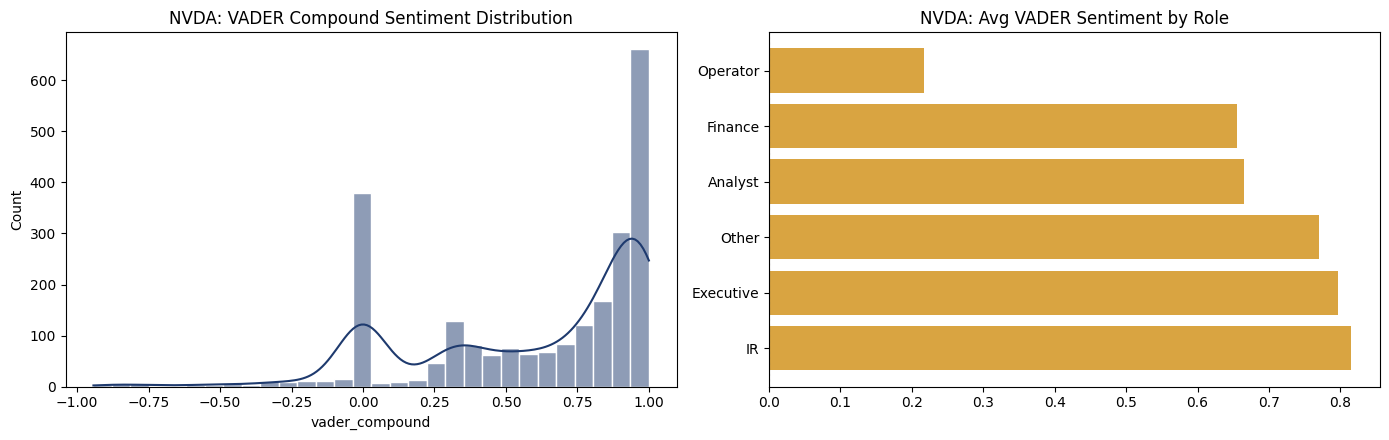

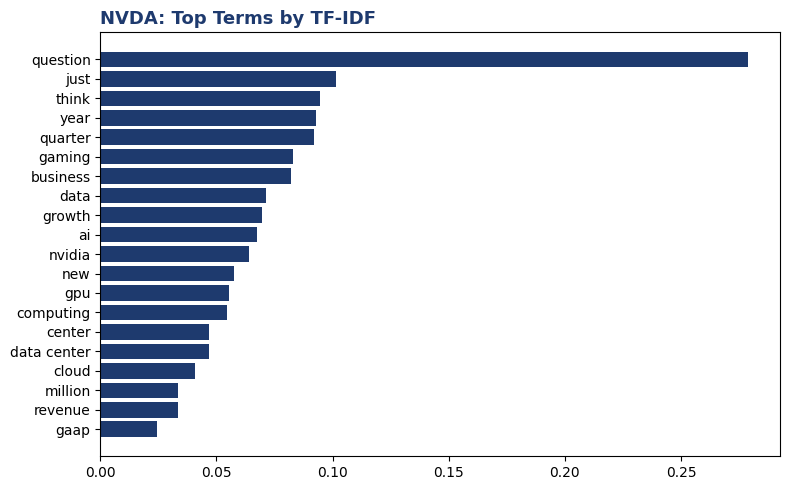

In [59]:
# Illustrative deep-dive: VADER sentiment + top terms for a single symbol (NVDA)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

focus_symbol = "NVDA"
nvda_turns = tx_turns.filter(pl.col("symbol") == focus_symbol).to_pandas()
analyzer = SentimentIntensityAnalyzer()
nvda_turns["vader_compound"] = nvda_turns["content"].astype(str).map(
    lambda t: analyzer.polarity_scores(t)["compound"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(nvda_turns["vader_compound"], bins=30, kde=True, ax=axes[0], color=NAVY)
axes[0].set_title(f"{focus_symbol}: VADER Compound Sentiment Distribution")

role_sent = nvda_turns.groupby("role")["vader_compound"].mean().sort_values(ascending=False)
axes[1].barh(role_sent.index, role_sent.values, color=GOLD)
axes[1].set_title(f"{focus_symbol}: Avg VADER Sentiment by Role")
axes[1].axvline(x=0, color="gray", linestyle=":")
plt.tight_layout()
plt.show()

tfidf = TfidfVectorizer(stop_words="english", max_features=20, ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf.fit_transform(nvda_turns.loc[nvda_turns["content_words"] > 0, "content"].astype(str))
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
term_frame = pd.DataFrame({"term": tfidf.get_feature_names_out(), "tfidf": tfidf_scores}).sort_values("tfidf", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(term_frame["term"][::-1], term_frame["tfidf"][::-1], color=NAVY)
ax.set_title(f"{focus_symbol}: Top Terms by TF-IDF", fontsize=13, fontweight="bold", color=NAVY, loc="left")
plt.tight_layout()
plt.show()

---
## 12. News Sentiment Analysis

News sentiment is engineered upstream (AlphaVantage News & Sentiment API, VADER-refined) into pre- and
post-earnings window aggregates. This section checks its distribution and relationship to the target.

shape: (9, 6)
┌────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ statistic  ┆ overall_sentime ┆ ticker_sentime ┆ overall_sentim ┆ ticker_sentime ┆ relevance_scor │
│ ---        ┆ nt_score_pre    ┆ nt_score_pre   ┆ ent_score_post ┆ nt_score_post  ┆ e_pre          │
│ str        ┆ ---             ┆ ---            ┆ ---            ┆ ---            ┆ ---            │
│            ┆ f64             ┆ f64            ┆ f64            ┆ f64            ┆ f64            │
╞════════════╪═════════════════╪════════════════╪════════════════╪════════════════╪════════════════╡
│ count      ┆ 24048.0         ┆ 24048.0        ┆ 24048.0        ┆ 24048.0        ┆ 24048.0        │
│ null_count ┆ 0.0             ┆ 0.0            ┆ 0.0            ┆ 0.0            ┆ 0.0            │
│ mean       ┆ 0.182376        ┆ 0.186482       ┆ 0.180166       ┆ 0.184441       ┆ 0.822205       │
│ std        ┆ 0.158855        ┆ 0.167164       ┆ 0.163866       ┆ 0.174395  

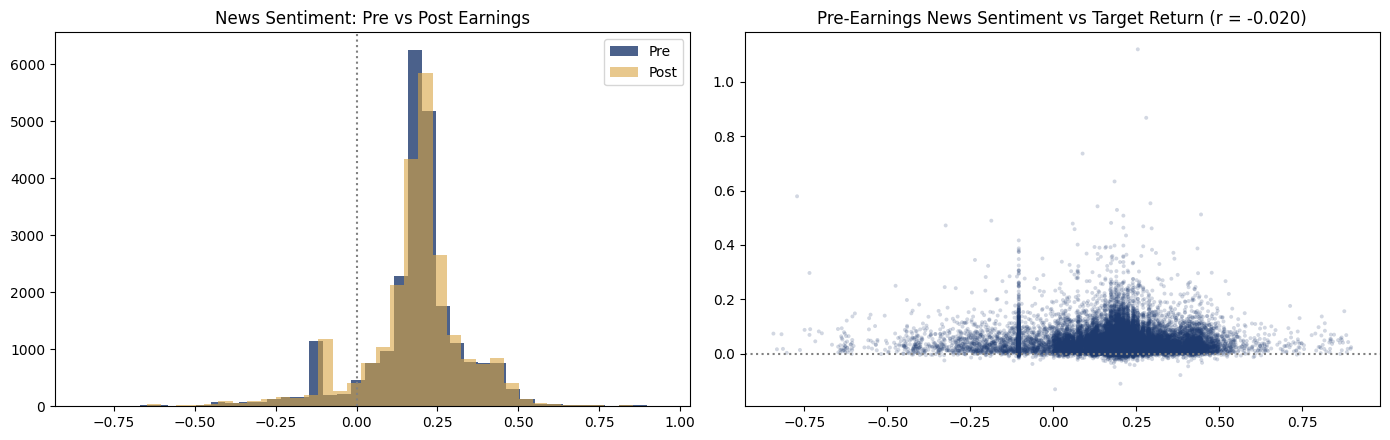

In [60]:
print(df_model.select(
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post", "relevance_score_pre",
).describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(df_model["overall_sentiment_score_pre"].drop_nulls().to_list(), bins=40, color=NAVY, alpha=0.8, label="Pre")
axes[0].hist(df_model["overall_sentiment_score_post"].drop_nulls().to_list(), bins=40, color=GOLD, alpha=0.6, label="Post")
axes[0].set_title("News Sentiment: Pre vs Post Earnings"); axes[0].legend()
axes[0].axvline(x=0, color="gray", linestyle=":")

news_scatter = df_model.select("overall_sentiment_score_pre", "target_return").drop_nulls()
axes[1].scatter(news_scatter["overall_sentiment_score_pre"].to_list(),
                 news_scatter["target_return"].to_list(), alpha=0.2, s=8, color=NAVY, edgecolors="none")
r_news = np.corrcoef(news_scatter["overall_sentiment_score_pre"].to_list(),
                      news_scatter["target_return"].to_list())[0, 1]
axes[1].set_title(f"Pre-Earnings News Sentiment vs Target Return (r = {r_news:.3f})")
axes[1].axhline(0, color="gray", linestyle=":")
plt.tight_layout()
plt.show()

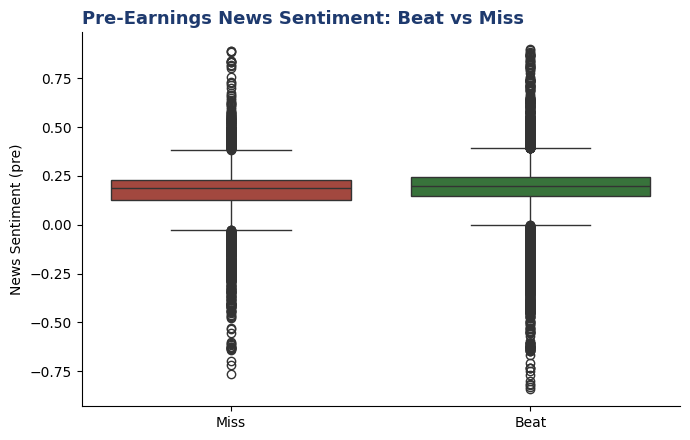

In [61]:
news_beat = df_model.select("overall_sentiment_score_pre", "beat").drop_nulls().to_pandas()
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=news_beat, x="beat", y="overall_sentiment_score_pre", ax=ax, palette=[RED, GREEN])
ax.set_xticklabels(["Miss", "Beat"])
ax.set_title("Pre-Earnings News Sentiment: Beat vs Miss", fontsize=13, fontweight="bold", color=NAVY, loc="left")
ax.set_xlabel(""); ax.set_ylabel("News Sentiment (pre)")
sns.despine()
plt.tight_layout()
plt.show()

---
## 14. Dimensionality Reduction Analysis

PCA input (after dropping inf/NaN rows): (23794, 229)


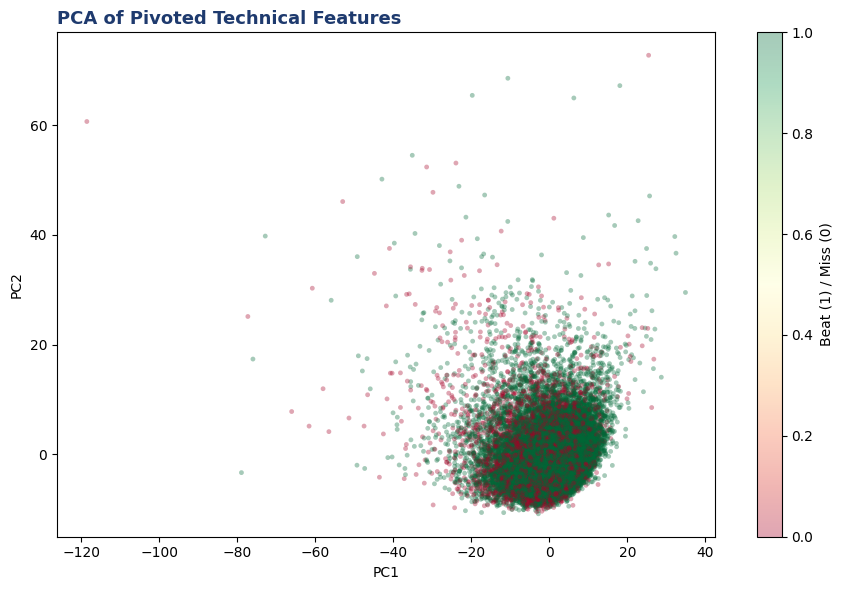

In [62]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_data = df_model.select(pivoted_cols).to_pandas()
pca_data = pca_data.replace([np.inf, -np.inf], np.nan).dropna()
print(f"PCA input (after dropping inf/NaN rows): {pca_data.shape}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

pca2 = PCA(n_components=2)
transformed = pca2.fit_transform(scaled_data)
labels_beat = df_model.select("beat").to_pandas().loc[pca_data.index, "beat"].values

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(transformed[:, 0], transformed[:, 1], c=labels_beat, cmap="RdYlGn", alpha=0.35, s=12, edgecolors="none")
plt.colorbar(sc, label="Beat (1) / Miss (0)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA of Pivoted Technical Features", fontsize=13, fontweight="bold", color=NAVY, loc="left")
plt.tight_layout()
plt.show()

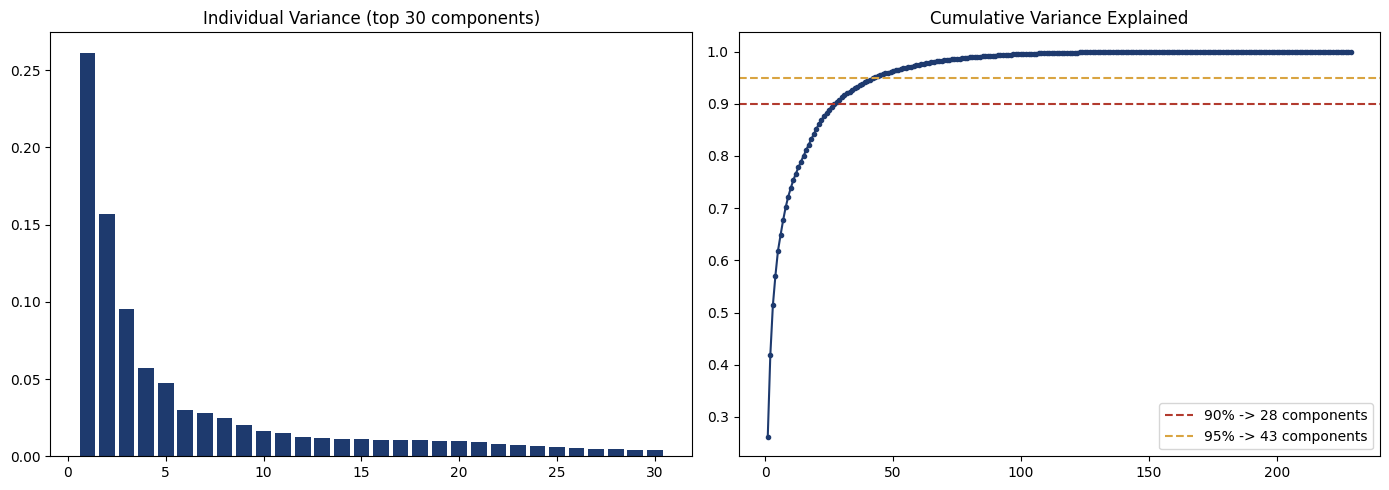

Original pivoted features: 229
Components for 90% variance: 28  (88% reduction)
Components for 95% variance: 43  (81% reduction)

Correlation-based selection (threshold=0.95): 111 redundant, 118 remaining


In [63]:
pca_full = PCA()
pca_full.fit(scaled_data)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_) + 1)), pca_full.explained_variance_ratio_[:30], color=NAVY)
axes[0].set_title("Individual Variance (top 30 components)")
axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker=".", color=NAVY)
axes[1].axhline(y=0.90, color=RED, linestyle="--", label=f"90% -> {n_90} components")
axes[1].axhline(y=0.95, color=GOLD, linestyle="--", label=f"95% -> {n_95} components")
axes[1].set_title("Cumulative Variance Explained"); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Original pivoted features: {len(pivoted_cols)}")
print(f"Components for 90% variance: {n_90}  ({100*(1 - n_90/len(pivoted_cols)):.0f}% reduction)")
print(f"Components for 95% variance: {n_95}  ({100*(1 - n_95/len(pivoted_cols)):.0f}% reduction)")

corr_abs = pca_data.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"\nCorrelation-based selection (threshold=0.95): {len(high_corr)} redundant, "
      f"{len(pivoted_cols) - len(high_corr)} remaining")

---
## 15. Summary of Findings & Preprocessing Plan

In [64]:
print("=" * 80)
print("EDA SUMMARY: KEY FINDINGS")
print("=" * 80)
print()
print("DATASET OVERVIEW")
print(f"  Events:      {df_model.shape[0]:,}")
print(f"  Symbols:     {df_model['symbol'].n_unique()}")
print(f"  Date range:  {df_model['earnings_date'].min()} to {df_model['earnings_date'].max()}")
print(f"  Features:    {df_model.shape[1]}")
print()
print("TARGET DISTRIBUTION")
for i in [0, 1, 2]:
    c = class_dist.filter(pl.col("target_class") == i)["count"].item()
    print(f"  {labels3[i]:16s}: {c:,} ({100*c/N:.1f}%)")
print(f"  Beat rate: {beat_rate:.1%}")
print()
print("PEAD SIGNAL")
print(f"  Beat t+1 drift: {beat_mean[10]:+.2f}%   Beat t+10 drift: {beat_mean[-1]:+.2f}%")
print(f"  Miss t+1 drift: {miss_mean[10]:+.2f}%   Miss t+10 drift: {miss_mean[-1]:+.2f}%")
print("  Beat and Miss profiles diverge after the announcement -> classic PEAD pattern")
print()
print("FEATURE CORRELATION")
print(f"  {flagged}/{pdf_all.shape[1]} features have |r| > 0.95 with another (redundant)")
print()
print("MISSING VALUES")
print(f"  {total_nulls:,} / {total_cells:,} cells missing ({100*total_nulls/total_cells:.2f}%)")
print("  Structurally explained: EMA warm-up window, first-event QoQ growth, news coverage")
print()
print("=" * 80)

EDA SUMMARY: KEY FINDINGS

DATASET OVERVIEW
  Events:      24,048
  Symbols:     503
  Date range:  2014-01-07 to 2026-05-14
  Features:    282

TARGET DISTRIBUTION
  Low (<2%)       : 7,955 (33.1%)
  Moderate (2-4%) : 6,428 (26.7%)
  Strong (>=4%)   : 9,665 (40.2%)
  Beat rate: 73.5%

PEAD SIGNAL
  Beat t+1 drift: +1.15%   Beat t+10 drift: +1.96%
  Miss t+1 drift: -1.55%   Miss t+10 drift: -0.94%
  Beat and Miss profiles diverge after the announcement -> classic PEAD pattern

FEATURE CORRELATION
  127/269 features have |r| > 0.95 with another (redundant)

MISSING VALUES
  17,839 / 6,685,344 cells missing (0.27%)
  Structurally explained: EMA warm-up window, first-event QoQ growth, news coverage



In [40]:
preprocessing_plan = [
    ("ema*_pct pivoted cols",     "Nulls for early-history events (EMA warm-up window)", "Median impute per symbol"),
    ("eps_growth_qoq",            "Null for first event per symbol",                     "Fill with 0 (no prior quarter)"),
    ("gross_margin / roe / etc.", "Sparse for a subset of symbols",                      "Median impute per sector"),
    ("news / analyst features",   "Not all events have coverage in the window",          "Fill with 0 / neutral + missingness flag"),
    ("inf values (pivoted)",      "Division-by-zero artifacts in a handful of ratios",   "Replace with NaN, then impute"),
    ("Highly correlated t0/lag features", "Multiple TA indicators encode similar info",  "Drop via 0.95 correlation filter before PCA/DNN"),
    ("beat (target)",             "Class imbalance",                                     "class_weight='balanced' or resampling"),
    ("transcript text",           "Missing for some events; ~boilerplate content present", "Strip boilerplate, use FinBERT aggregate as feature"),
]

print(f"{'Column Group':<32} {'Issue':<48} {'Strategy'}")
print("-" * 120)
for col, issue, strategy in preprocessing_plan:
    print(f"{col:<32} {issue:<48} {strategy}")

Column Group                     Issue                                            Strategy
------------------------------------------------------------------------------------------------------------------------
ema*_pct pivoted cols            Nulls for early-history events (EMA warm-up window) Median impute per symbol
eps_growth_qoq                   Null for first event per symbol                  Fill with 0 (no prior quarter)
gross_margin / roe / etc.        Sparse for a subset of symbols                   Median impute per sector
news / analyst features          Not all events have coverage in the window       Fill with 0 / neutral + missingness flag
inf values (pivoted)             Division-by-zero artifacts in a handful of ratios Replace with NaN, then impute
Highly correlated t0/lag features Multiple TA indicators encode similar info       Drop via 0.95 correlation filter before PCA/DNN
beat (target)                    Class imbalance                                  class_wei